# Train and Tune Stacking Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.stacking import StackingEnsemble
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, \
    plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-09-02 20:05:41,295 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "stacking"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: StackingEnsemble(horizon=horizon, random_state=seed),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=30, n_splits=2)

2025-09-02 20:05:41,356 - INFO - ModelTrainer - Initialized ModelTrainer for model: stacking
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [80, 250] and step=20, but the range is not divisible by `step`. It will be replaced by [80, 240].
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [80, 250] and step=20, but the range is not divisible by `step`. It will be replaced by [80, 240].
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [80, 250] and step=20, but the range is not divisible by `step`. It will be replaced by [80, 240].
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [80, 250] and step=20, but the range is not divisible by `s

In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

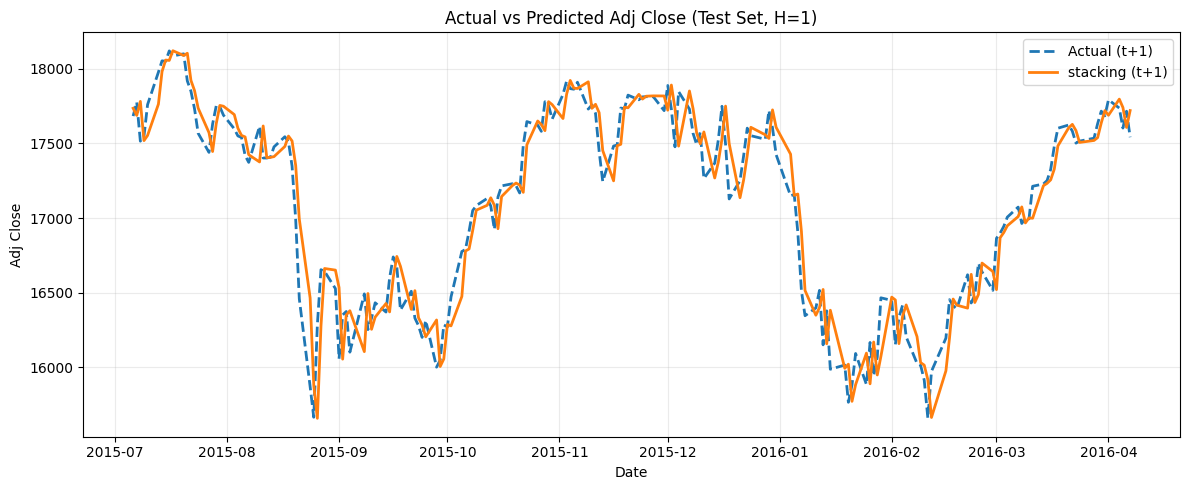

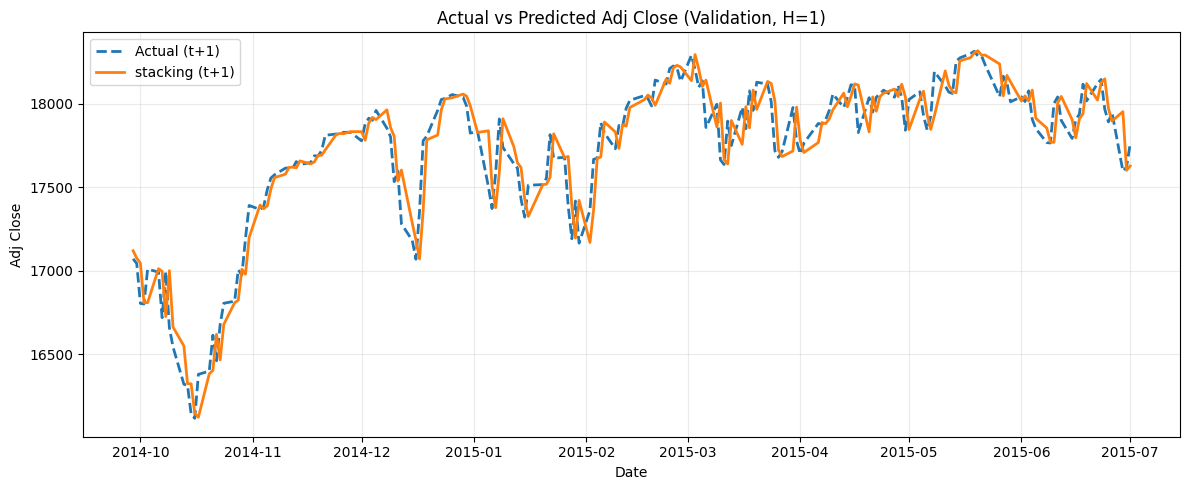

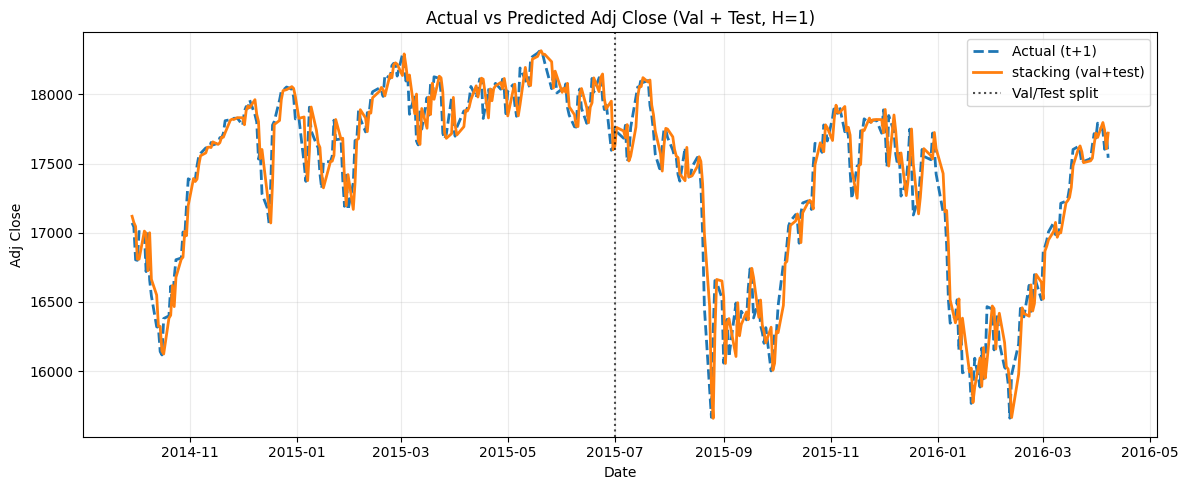

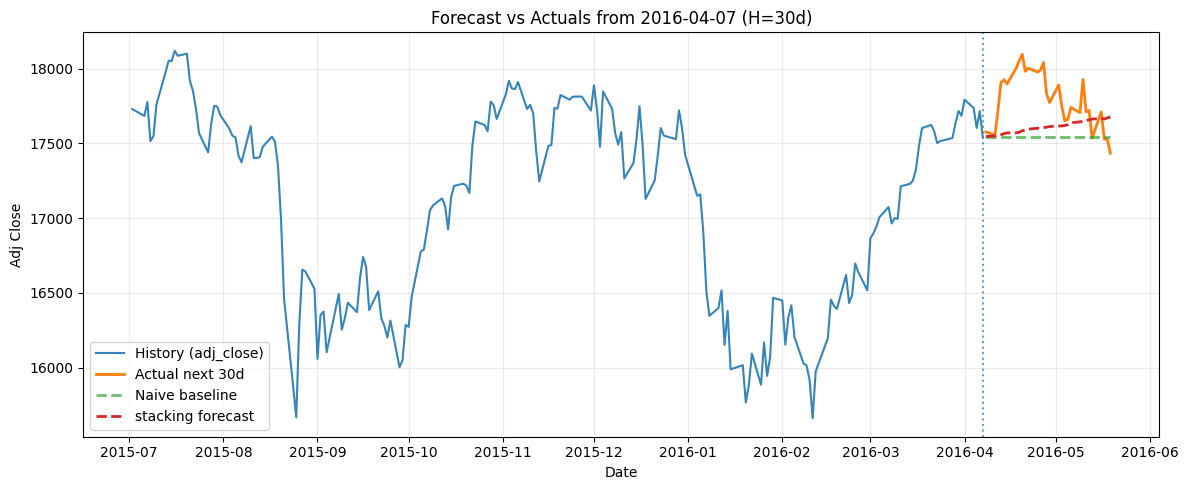

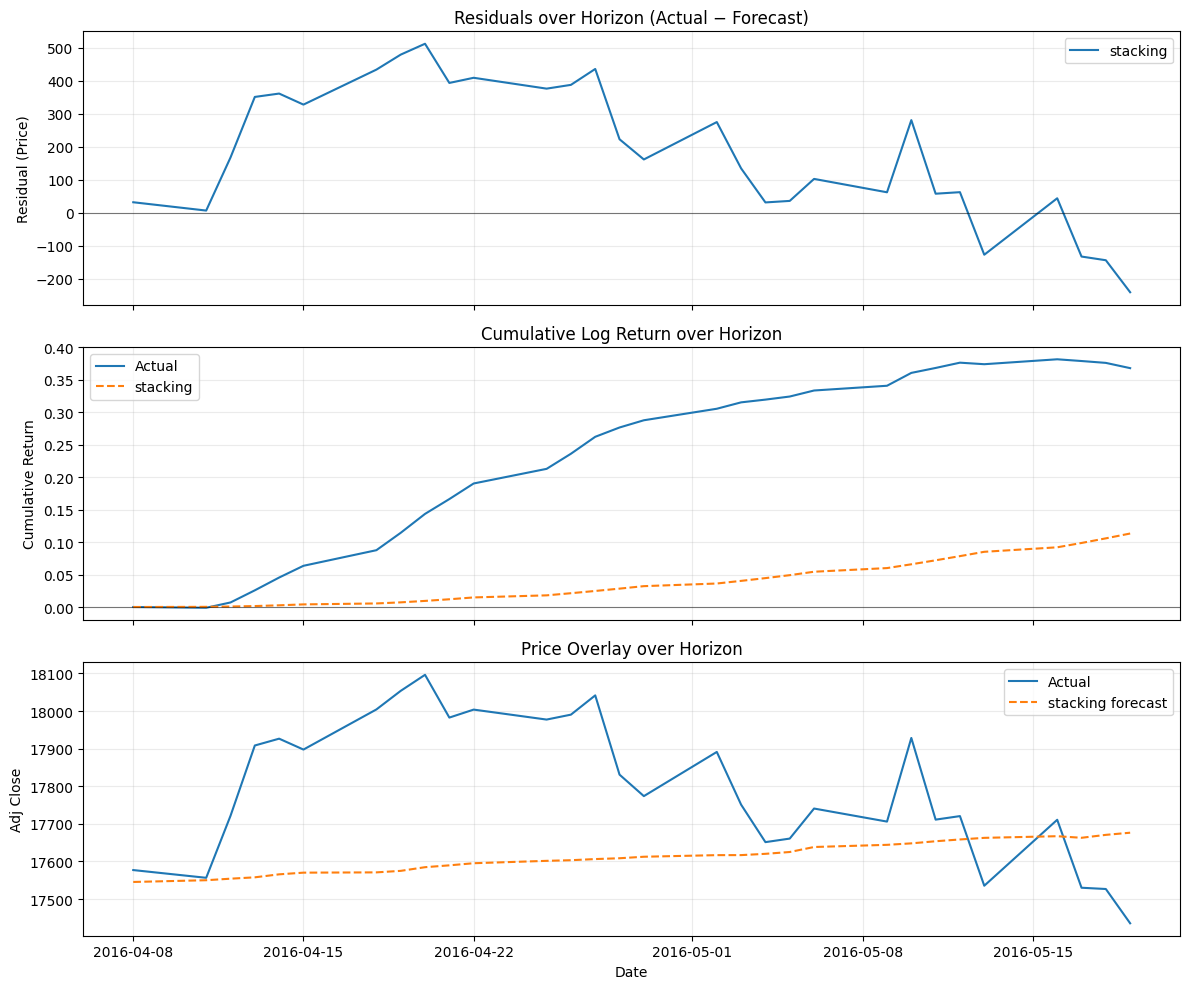

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
pd.DataFrame(results[0]["best_params"], index=[0])

,ridge_alpha,rf_estimators,xgb_estimators,xgb_max_depth,xgb_learning_rate,drop_rf,drop_lin,passthrough,random_state
0,6.609111,150,120,5,0.057698,True,True,False,42


In [9]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,0.008264,0.000121,0.010983,1.844914,-0.000404


In [10]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()